<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/XR/KBr/Lab4_Bragg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab4 XR Bragg experiment

Evgeny Kolonsky 2026

Wavelengths
$$
n \lambda = 2 d \sin \theta
$$

Energy
$$
E = \frac{hc}{\lambda}
$$

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.constants import c, h, electron_volt as eV
import requests
from io import BytesIO
from PIL import Image

URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/XR/KBr/'

1: Angle 5.60 deg at order 1, wavelength 0.644 Å, Energy 19.251 keV
1: Angle 6.30 deg at order 1, wavelength 0.724 Å, Energy 17.119 keV
1: Angle 8.60 deg at order 1, wavelength 0.987 Å, Energy 12.563 keV
1: Angle 11.10 deg at order 1, wavelength 1.271 Å, Energy 9.758 keV
1: Angle 12.50 deg at order 1, wavelength 1.429 Å, Energy 8.679 keV
1: Angle 18.90 deg at order 2, wavelength 1.069 Å, Energy 11.599 keV
2: Angle 5.50 deg at order 1, wavelength 0.633 Å, Energy 19.600 keV
2: Angle 6.20 deg at order 1, wavelength 0.713 Å, Energy 17.394 keV
2: Angle 8.30 deg at order 1, wavelength 0.953 Å, Energy 13.013 keV
2: Angle 12.50 deg at order 1, wavelength 1.429 Å, Energy 8.679 keV
2: Angle 18.80 deg at order 2, wavelength 1.063 Å, Energy 11.658 keV
3: Angle 5.60 deg at order 1, wavelength 0.644 Å, Energy 19.251 keV
3: Angle 6.30 deg at order 1, wavelength 0.724 Å, Energy 17.119 keV
3: Angle 8.60 deg at order 1, wavelength 0.987 Å, Energy 12.563 keV
3: Angle 11.20 deg at order 1, wavelength 1.28

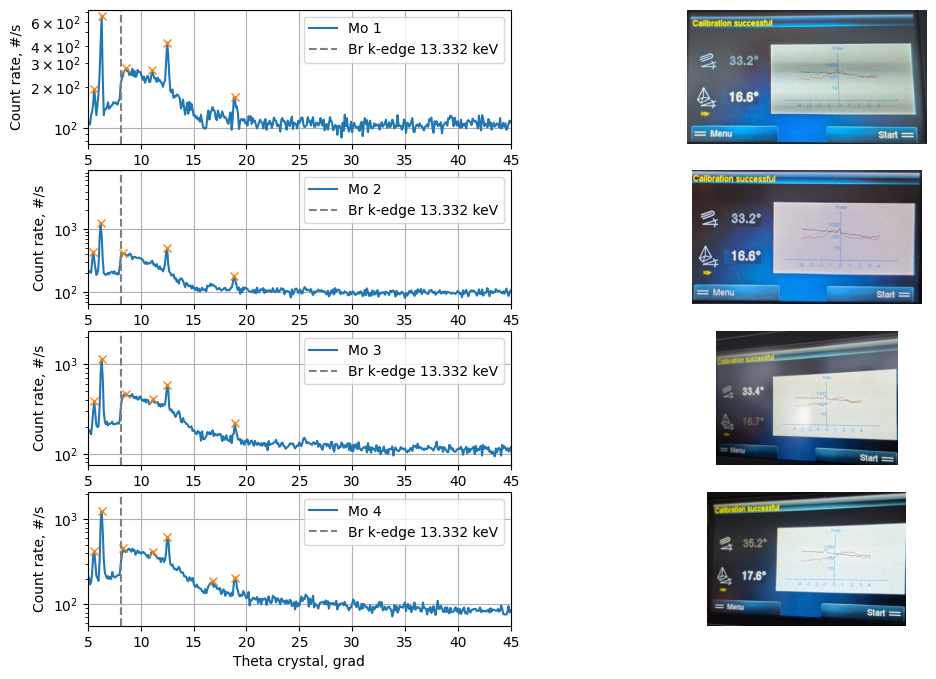

In [47]:
crystal = 'KBr'
d = 330e-12 #m
lamp = 'Mo'

fig, axs = plt.subplots(4, 2, figsize=(12, 8))
for n in  [1,2,3,4]:
  ax = axs[n-1,0]
  filename = URL + f'{lamp}_{crystal}_{n}.txt'
  theta, count = np.genfromtxt(filename, skip_header=3, unpack=True, encoding='latin1')
  theta_rad = theta * np.pi / 180
  peaks, _ = find_peaks(count, prominence=50)
  ax.plot(theta, count,  label=f'{lamp} {n}')
  ax.plot(theta[peaks], count[peaks], 'x')

  k_edge = 8.1 # degrees
  l = 2 * d * np.sin(k_edge * np.pi / 180)
  E = h * c / l
  ax.axvline(x=k_edge, color='gray', ls='--', label=f'Br k-edge {E/eV /1e3:.3f} keV')

  ax.set_yscale('log')
  ax.set_xlabel('Theta crystal, grad')
  ax.set_ylabel('Count rate, #/s')
  ax.grid(True)
  ax.legend()
  ax.set_xlim(5, 45)

  # photo of calibration
  ax = axs[n-1,1]
  filename = URL + f'{lamp}_{crystal}_{n}.jpg'
  response = requests.get(filename, headers={"User-Agent": "Mozilla/5.0"})
  image = Image.open(BytesIO(response.content))
  ax.imshow(image)
  ax.axis("off")  # Hides grid lines and pixel axes

  for peak in peaks:
    if theta[peak] < 15:
      order = 1
    elif theta[peak] < 30:
      order = 2
    else:
      order = 3
    l = 2 * d * np.sin(theta_rad[peak]) / order
    E = h * c / l
    print(f'{n}: Angle {theta[peak]:.2f} deg at order {order}, wavelength {l*1e10:.3f} Å, Energy {E/eV /1e3:.3f} keV')

# Ferrum amd Cuprum lamps



4: Angle 8.40 deg at order 1, wavelength 0.964 Å, Energy 12.859 keV
4: Angle 15.40 deg at order 2, wavelength 0.876 Å, Energy 14.148 keV
4: Angle 17.10 deg at order 2, wavelength 0.970 Å, Energy 12.777 keV
4: Angle 32.10 deg at order 3, wavelength 1.169 Å, Energy 10.605 keV
4: Angle 35.90 deg at order 3, wavelength 1.290 Å, Energy 9.611 keV
4: Angle 52.90 deg at order 3, wavelength 1.755 Å, Energy 7.066 keV
4: Angle 61.50 deg at order 3, wavelength 1.933 Å, Energy 6.413 keV
4: Angle 9.20 deg at order 1, wavelength 1.055 Å, Energy 11.750 keV
4: Angle 12.30 deg at order 1, wavelength 1.406 Å, Energy 8.818 keV
4: Angle 13.60 deg at order 1, wavelength 1.552 Å, Energy 7.989 keV
4: Angle 25.00 deg at order 2, wavelength 1.395 Å, Energy 8.890 keV
4: Angle 27.90 deg at order 2, wavelength 1.544 Å, Energy 8.029 keV
4: Angle 39.30 deg at order 3, wavelength 1.393 Å, Energy 8.898 keV
4: Angle 44.50 deg at order 3, wavelength 1.542 Å, Energy 8.040 keV
4: Angle 57.50 deg at order 3, wavelength 1.8

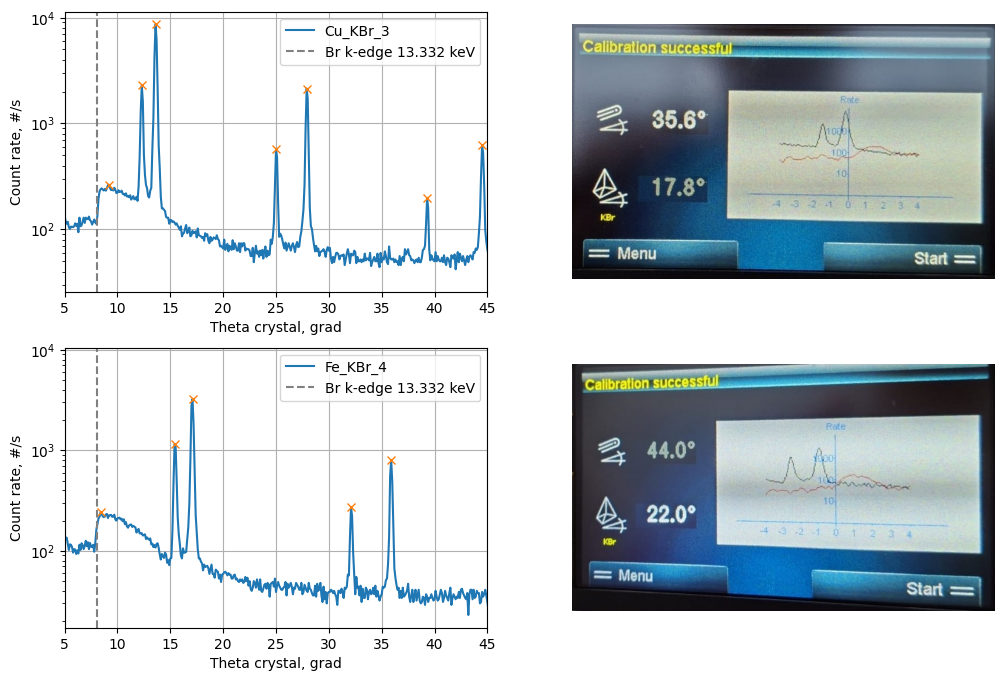

In [48]:
crystal = 'KBr'
d = 330e-12 #m
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for i, filename  in  enumerate(['Fe_KBr_4', 'Cu_KBr_3']):
  ax = axs[i-1,0]
  theta, count = np.genfromtxt(URL+filename+'.txt', skip_header=3, unpack=True, encoding='latin1')
  theta_rad = theta * np.pi / 180
  peaks, _ = find_peaks(count, prominence=50)
  ax.plot(theta, count,  label=f'{filename}')
  ax.plot(theta[peaks], count[peaks], 'x')

  k_edge = 8.1 # degrees
  l = 2 * d * np.sin(k_edge * np.pi / 180)
  E = h * c / l
  ax.axvline(x=k_edge, color='gray', ls='--', label=f'Br k-edge {E/eV /1e3:.3f} keV')

  ax.set_yscale('log')
  ax.set_xlabel('Theta crystal, grad')
  ax.set_ylabel('Count rate, #/s')
  ax.grid(True)
  ax.legend()
  ax.set_xlim(5, 45)

  # photo of calibration
  ax = axs[i-1,1]
  filename = URL + filename +'.jpg'
  response = requests.get(filename, headers={"User-Agent": "Mozilla/5.0"})
  image = Image.open(BytesIO(response.content))
  ax.imshow(image)
  ax.axis("off")  # Hides grid lines and pixel axes


  for peak in peaks:
    if theta[peak] < 15:
      order = 1
    elif theta[peak] < 30:
      order = 2
    else:
      order = 3
    l = 2 * d * np.sin(theta_rad[peak]) / order
    E = h * c / l
    print(f'{n}: Angle {theta[peak]:.2f} deg at order {order}, wavelength {l*1e10:.3f} Å, Energy {E/eV /1e3:.3f} keV')

In [49]:
url

'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/XR/KBr/Fe_KBr_4.jpg'